In [1]:

import numpy as np
import cvxpy as cp
import pickle as pkl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
eta = 0.945
def optimize_battery_hourly_cvxpy(y, I0, I_target, Imax, Bmin, Bmax, c):
    """
    Quadratic DA optimization:

        linprog version (your LP) solves:
            min_{B,I} sum_k y_k * B_k
        and then sets profit = - sum_k y_k * B_k

    This function solves the quadratic extension:
        min_{B,I} sum_k y_k * B_k + c * sum_k B_k^2
    and returns
        profit = - (sum_k y_k * B_k + c * sum_k B_k^2)

    So when c = 0, this matches the LP exactly (same B_opt, I_opt, profit).
    """

    y = np.asarray(y, dtype=float)
    T = len(y)
    B_ch = cp.Variable(T,nonneg = True)
    B_disch = cp.Variable(T,nonneg= True)
    I = cp.Variable(T + 1)   # I_0,...,I_T
    B = B_ch - B_disch

    constraints = []

    # Initial SoC
    constraints.append(I[0] == I0)

    # SoC dynamics: I_{k+1} = I_k + B_k
    for k in range(T):
        constraints.append(I[k+1] == I[k] + eta * B_ch[k] - (1.0/eta) * B_disch[k])

    # SoC bounds
    constraints.append(I >= 0)
    constraints.append(I <= Imax)

    # Power bounds
    constraints.append(B >= Bmin)
    constraints.append(B <= Bmax)

    # Optional terminal constraint
    if I_target is not None:
        constraints.append(I[T] == I_target)

    # Objective: **minimize** sum(y_k B_k) + c * sum(B_k^2)
    obj = cp.Minimize(y @ B + (1/2)* c * cp.sum_squares(B))

    prob = cp.Problem(obj, constraints)
    prob.solve(solver=cp.OSQP)  # OSQP is good for QPs

    if prob.status not in ["optimal", "optimal_inaccurate"]:
        raise RuntimeError(f"Optimization failed: {prob.status}")

    B_opt = B.value
    I_opt = I.value

    # Same profit definition as in linprog version, extended with the quadratic term
    profit = - (float(y @ B_opt) + float(c * np.sum(B_opt**2)))

    return np.array(B_opt), np.array(I_opt), profit



def plot_lp_result(y, B_opt, I_opt, title="LP schedule from avg LMP"):
    T = len(y)
    t = np.arange(T)
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True, constrained_layout=True)

    # ---- (1) price with shading ----
    ax = axes[0]
    for k, Bk in enumerate(B_opt):
        if Bk > 1e-3:     # charge
            ax.axvspan(k, k+1, alpha=0.18, color='khaki')
        elif Bk < -1e-3:  # discharge
            ax.axvspan(k, k+1, alpha=0.20, color='lightgray')
    ax.plot(t, y, marker='o', lw=2, color='black')
    ax.set_ylabel(r"90-day avg DA LMP ($/MWh)")
    ax.set_title(title)

    # ---- (2) power B_k ----
    axB = axes[1]
    for k, Bk in enumerate(B_opt):
        if Bk > 1e-3:
            axB.axvspan(k, k+1, alpha=0.18, color='khaki')
        elif Bk < -1e-3:
            axB.axvspan(k, k+1, alpha=0.20, color='lightgray')
    axB.axhline(0, color='k', lw=1, alpha=0.5)
    axB.plot(t, B_opt, marker='s', lw=2)
    axB.set_ylabel(r"$B^{DA}$ (MW)")

    # ---- (3) SoC ----
    axI = axes[2]

    axI.step(np.arange(T+1), I_opt, where='post', lw=2)
    axI.set_xlabel("Hour")
    axI.set_ylabel(r"$I^{DA}$ (MWh)")
    axI.set_xlim(0, T)

    legend_elems = [
        Patch(facecolor='khaki', alpha=0.18, label='Charge (B>0)'),
        Patch(facecolor='lightgray', alpha=0.20, label='Discharge (B<0)')
    ]
    axes[0].legend(handles=legend_elems, loc='upper left')

    for a in axes:
        a.grid(True, alpha=0.3)

    plt.show()


In [2]:
with open('cubic_spline.pkl', 'rb') as f:
    spline = pkl.load(f)
DA_curve = lambda t: spline['cs'](t)

In [3]:
t = np.arange(24)
DA_lmp = DA_curve(t)

(24,) (25,)
Profit (with no quadratic penalty): 5.06427117426606


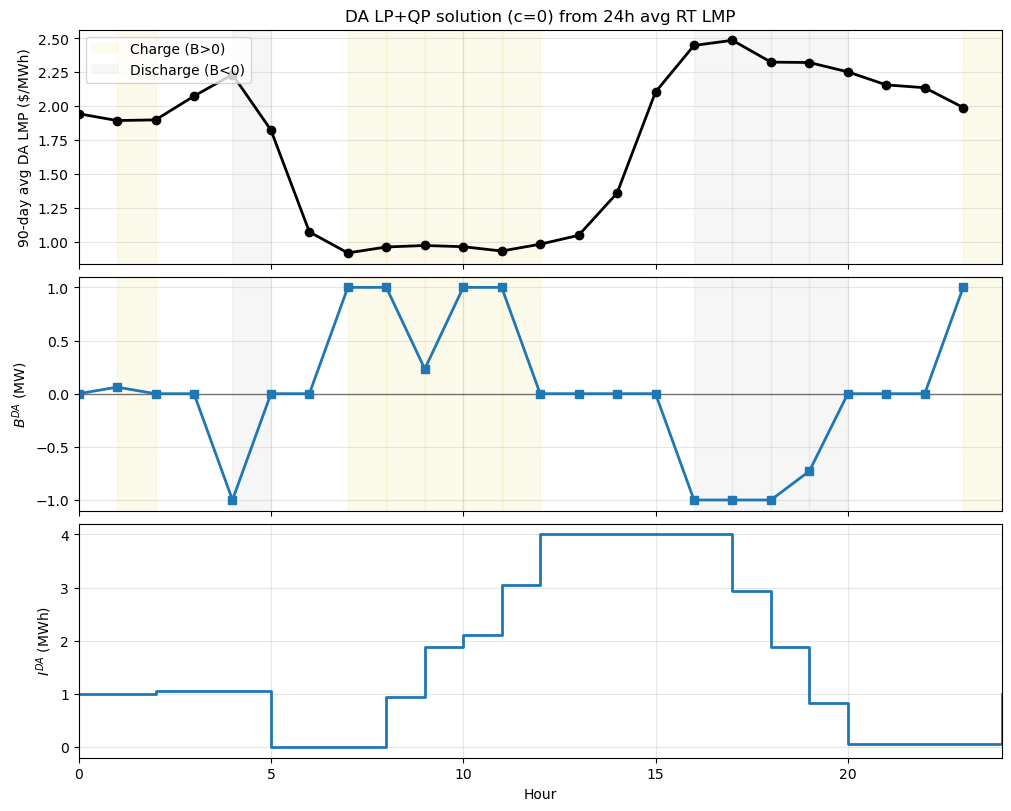

[ 2.03792599e-05  6.13283873e-02  2.74277667e-05  3.38156839e-05
 -9.99955266e-01  8.93377065e-06 -6.09448586e-07  9.99989295e-01
  9.99990766e-01  2.32864073e-01  9.99990888e-01  9.99989535e-01
 -2.97416719e-06 -5.63602488e-07  5.55597409e-07  2.78157041e-06
 -9.99986961e-01 -9.99987953e-01 -9.99989499e-01 -7.28151703e-01
  1.04209875e-05  1.30459217e-05  1.46747753e-05  1.00001320e+00]


In [4]:
B_opt, I_opt, profit = optimize_battery_hourly_cvxpy(
    DA_lmp/ 20, I0=1.0, I_target=1.0, Imax=4, Bmin=-1, Bmax=1,c=0.0
)

print(B_opt.shape,I_opt.shape)
print("Profit (with no quadratic penalty):", profit)
plot_lp_result(DA_lmp/20, B_opt, I_opt,
               title=f"DA LP+QP solution (c={0}) from 24h avg RT LMP")

print(B_opt)

In [5]:
I_opt

array([ 1.00000002e+00,  1.00004190e+00,  1.05800498e+00,  1.05806134e+00,
        1.05813084e+00, -2.76394657e-05, -9.27406713e-06, -1.04868905e-05,
        9.44979297e-01,  1.88997048e+00,  2.11002670e+00,  3.05501800e+00,
        4.00000802e+00,  4.00000217e+00,  4.00000106e+00,  4.00000220e+00,
        4.00000792e+00,  2.94181930e+00,  1.88362973e+00,  8.25438687e-01,
        5.49075932e-02,  5.49290283e-02,  5.49558638e-02,  5.49860505e-02,
        9.99999985e-01])

In [6]:
from main import OU_w_derivative, RTRunningCost, softSoC_Constraint, ShadowGPTrainer

# Use DA greedy schedule from previous cell
B_DA_24 = np.asarray(B_opt, dtype=float)

# Parameters requested
rt_adjustment_pen = 0.2
da_pen = 0.0
final_SoC_penalty = 5.0
initialSoC = 1.0
terminal_SoCtarget = 1.0

# Other run settings (matching trainer defaults)
nstep = 96
ndecisions = 96
nsim = 10000
maturity = 24
ou_alpha = 0.1
ou_sigma = 0.05
ou_sigma0 = 0.25
Bmax = 1.0
Bmin = -1.0
SoCmax = 4.0
charging_eff = 0.95
x0_seed = 1234
ou_seed = 1234
design_seed = 1234
one_step_seed = 1234
nsim_design = 100
batch_size = 10
fence = 10

# Price curve from spline
with open('cubic_spline.pkl', 'rb') as f:
    spline = pkl.load(f)
RT_M_func = lambda t: spline['cs'](t) / 20
RT_dM_func = lambda t: spline['csd'](t) / 20
DA_M_func = lambda t: spline['cs'](t) / 20

np.random.seed(x0_seed)
X0 = np.random.normal(RT_M_func(0), ou_sigma0, size=nsim)

process = OU_w_derivative(
    X0=X0,
    nstep=nstep,
    nsim=nsim,
    maturity=maturity,
    alpha=ou_alpha,
    meanRevRate_func=RT_M_func,
    dmeanRevRate_func=RT_dM_func,
    sigma=ou_sigma,
    noises=None,
    seed=ou_seed,
)

running_cost = RTRunningCost(penalty=rt_adjustment_pen)
final_cost = softSoC_Constraint(
    charging_efficiency=charging_eff,
    SoC_max=SoCmax,
    SoC_target=terminal_SoCtarget,
    penalty_coeff=final_SoC_penalty,
)

assert ndecisions % maturity == 0
rep_factor = int(ndecisions // maturity)
B_DA_vec = np.repeat(B_DA_24, rep_factor)

trainer = ShadowGPTrainer(
    process=process,
    BESSparameters=(Bmax, Bmin, B_DA_vec, SoCmax, charging_eff),
    running_cost=running_cost,
    final_cost=final_cost,
    nsim_design=nsim_design,
    batch_size=batch_size,
    ndecisions=ndecisions,
)

trainer.fit(design_seed=design_seed, one_step_seed=one_step_seed, fence=fence)


Training policy_map[95] ...
policy_map[95] MSE: 2.0367832289071995e-09
Training continuation_map at decision k=94 ...
continuation_map[94] MSE: 3.2111463916592544e-05
Training policy_map[94] ...
policy_map[94] MSE: 1.0080965162005294e-10
Training continuation_map at decision k=93 ...
continuation_map[93] MSE: 0.00018805942640906994
Training policy_map[93] ...
policy_map[93] MSE: 2.0604447338221936e-10
Training continuation_map at decision k=92 ...
continuation_map[92] MSE: 0.0002947094443825961
Training policy_map[92] ...
policy_map[92] MSE: 6.358400860987013e-11
Training continuation_map at decision k=91 ...
continuation_map[91] MSE: 0.0005087224238002808
Training policy_map[91] ...
policy_map[91] MSE: 1.1009273740822236e-10
Training continuation_map at decision k=90 ...
continuation_map[90] MSE: 0.0005270958472047724
Training policy_map[90] ...
policy_map[90] MSE: 2.221749884618037e-11
Training continuation_map at decision k=89 ...
continuation_map[89] MSE: 0.0009667319514814355
Trai

 /Users/taung/miniconda3/envs/energy_mike/lib/python3.10/site-packages/GPy/kern/src/stationary.py:243: RuntimeWarning:invalid value encountered in divide


policy_map[30] MSE: 1.8207558447322732e-07
Training continuation_map at decision k=29 ...
continuation_map[29] MSE: 0.00018442779302978269
Training policy_map[29] ...
policy_map[29] MSE: 3.1961121739714216e-13
Training continuation_map at decision k=28 ...
continuation_map[28] MSE: 0.00021984963881729972
Training policy_map[28] ...
policy_map[28] MSE: 8.98953724519271e-13
Training continuation_map at decision k=27 ...
continuation_map[27] MSE: 0.00017078183885879187
Training policy_map[27] ...
policy_map[27] MSE: 7.9724681627613e-16
Training continuation_map at decision k=26 ...
continuation_map[26] MSE: 0.0002569541575640624
Training policy_map[26] ...
policy_map[26] MSE: 9.050216764321139e-15
Training continuation_map at decision k=25 ...
continuation_map[25] MSE: 0.00026803505294504973
Training policy_map[25] ...
policy_map[25] MSE: 2.62361232435326e-14
Training continuation_map at decision k=24 ...
continuation_map[24] MSE: 0.00036668072844199984
Training policy_map[24] ...
policy_

{'t_dec': [0.0,
  0.25,
  0.5,
  0.75,
  1.0,
  1.25,
  1.5,
  1.75,
  2.0,
  2.25,
  2.5,
  2.75,
  3.0,
  3.25,
  3.5,
  3.75,
  4.0,
  4.25,
  4.5,
  4.75,
  5.0,
  5.25,
  5.5,
  5.75,
  6.0,
  6.25,
  6.5,
  6.75,
  7.0,
  7.25,
  7.5,
  7.75,
  8.0,
  8.25,
  8.5,
  8.75,
  9.0,
  9.25,
  9.5,
  9.75,
  10.0,
  10.25,
  10.5,
  10.75,
  11.0,
  11.25,
  11.5,
  11.75,
  12.0,
  12.25,
  12.5,
  12.75,
  13.0,
  13.25,
  13.5,
  13.75,
  14.0,
  14.25,
  14.5,
  14.75,
  15.0,
  15.25,
  15.5,
  15.75,
  16.0,
  16.25,
  16.5,
  16.75,
  17.0,
  17.25,
  17.5,
  17.75,
  18.0,
  18.25,
  18.5,
  18.75,
  19.0,
  19.25,
  19.5,
  19.75,
  20.0,
  20.25,
  20.5,
  20.75,
  21.0,
  21.25,
  21.5,
  21.75,
  22.0,
  22.25,
  22.5,
  22.75,
  23.0,
  23.25,
  23.5,
  23.75],
 't_terminal': 24,
 'continuation_mse_by_step': [0.00042399518304585976,
  0.00044326107109691413,
  0.00038879957468076446,
  0.0003800183043453774,
  0.00045620663977647156,
  0.000341796733486079,
  0.0003228010

DA value:     5.064271
RT value:     0.531998
TOTAL profit: 5.596269


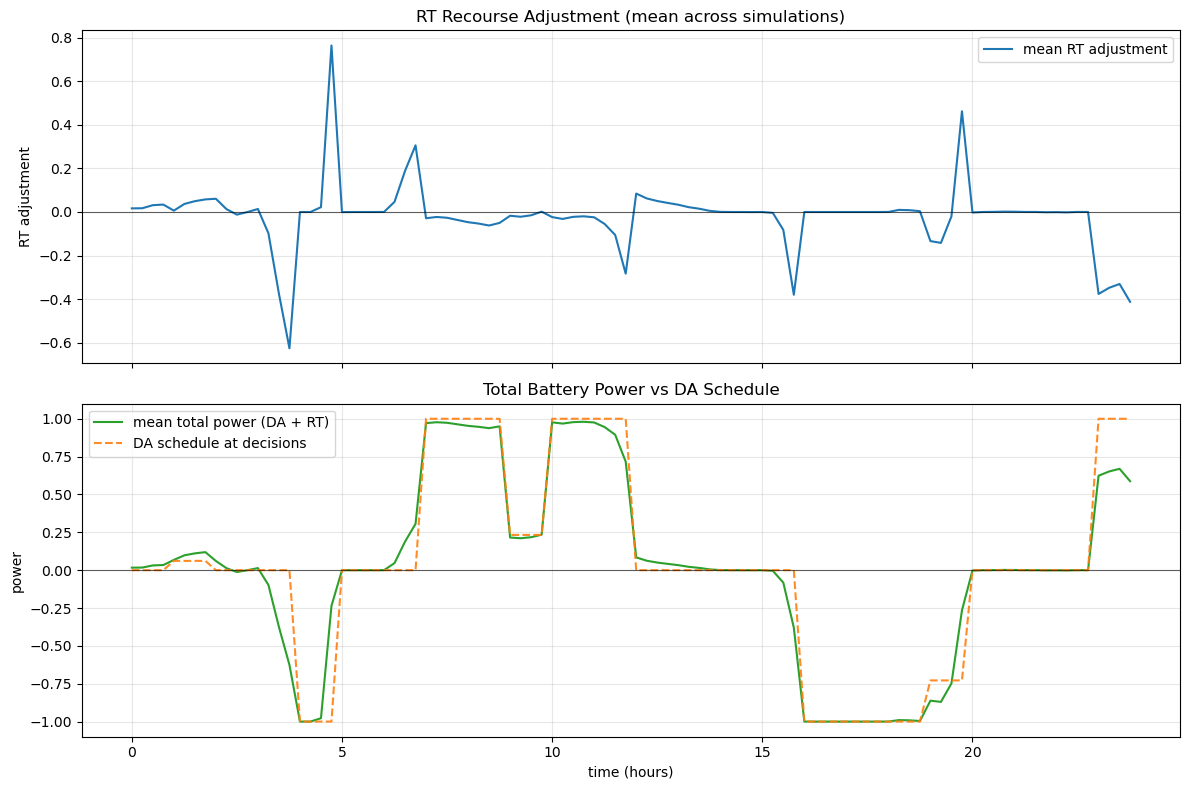

In [7]:

# Rollout to compute RT/DA/total profit and diagnostics
I0 = initialSoC
X_sims = trainer.process.sim_trajectories
nsim = X_sims.shape[0]
ndec = trainer.ndecisions
dt_opt = trainer.dt_opt
decision_idx = trainer.decision_idx
B_DA = trainer.B_DA

Is = np.zeros((nsim, ndec + 1))
Is[:, 0] = I0
B_rt_mat = np.zeros((nsim, ndec))
P_total_mat = np.zeros((nsim, ndec))
running_profit = np.zeros((nsim, ndec))

for k in range(ndec):
    Ilb, Iub = 0.0, trainer.Imax
    I_k = Is[:, k]
    idx_end = decision_idx[k]
    Price_end = X_sims[:, idx_end]
    B_DA_k = B_DA[k]

    LB = np.maximum(
        trainer.Bmin_scalar - B_DA_k,
        (trainer.charging_eff * (Ilb - I_k) / dt_opt) - B_DA_k,
    )
    UB = np.minimum(
        trainer.Bmax_scalar - B_DA_k,
        ((Iub - I_k) / (trainer.charging_eff * dt_opt)) - B_DA_k,
    )

    inp = np.column_stack((Price_end, I_k))
    B_rt = trainer.policy_maps[k].predict(inp)[0].flatten()
    B_rt = np.minimum(np.maximum(B_rt, LB), UB)

    P_total = B_DA_k + B_rt
    eff = trainer.charging_eff * (P_total > 0) + (1 / trainer.charging_eff) * (P_total < 0)
    Is[:, k + 1] = np.clip(I_k + P_total * eff * dt_opt, Ilb, Iub)

    B_rt_mat[:, k] = B_rt
    P_total_mat[:, k] = P_total
    running_profit[:, k] = -running_cost.cost(B_rt, Price_end, B_DA_k) * dt_opt

RT_value = float(np.mean(np.sum(running_profit, axis=1) - final_cost.cost(Is[:, -1])))
hours = np.linspace(0, 23, 24)
DA_prices = DA_M_func(hours)
DA_profit_energy = -np.sum(B_DA_24 * DA_prices)
DA_value = float(DA_profit_energy - np.abs((B_DA_24[1:] - B_DA_24[:-1])).sum() * da_pen)
TOTAL_profit = DA_value + RT_value

print(f'DA value:     {DA_value:.6f}')
print(f'RT value:     {RT_value:.6f}')
print(f'TOTAL profit: {TOTAL_profit:.6f}')

# Plots: RT adjustment and total battery power (DA + RT adj)
t_dec = trainer.t_dec
B_DA_dec = B_DA
mean_rt_adj = B_rt_mat.mean(axis=0)
mean_total_power = P_total_mat.mean(axis=0)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(t_dec, mean_rt_adj, label='mean RT adjustment', color='tab:blue')
axes[0].axhline(0.0, color='black', linewidth=0.8, alpha=0.6)
axes[0].set_ylabel('RT adjustment')
axes[0].set_title('RT Recourse Adjustment (mean across simulations)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(t_dec, mean_total_power, label='mean total power (DA + RT)', color='tab:green')
axes[1].plot(t_dec, B_DA_dec, '--', label='DA schedule at decisions', color='tab:orange', alpha=0.9)
axes[1].axhline(0.0, color='black', linewidth=0.8, alpha=0.6)
axes[1].set_xlabel('time (hours)')
axes[1].set_ylabel('power')
axes[1].set_title('Total Battery Power vs DA Schedule')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

